 ### 1) Import Libraries & SetUp

In [ ]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import preprocessing
from collections import Counter

# For NLP
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

# For ML Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Download stopwords (first time only)
nltk.download('stopwords')

plt.rcParams.update({
    'figure.facecolor': '#0f1117', 'axes.facecolor': '#1a1d27',
    'axes.edgecolor': '#2e3250', 'axes.labelcolor': '#c8cfe8',
    'axes.titlecolor': '#ffffff', 'xtick.color': '#8890b0',
    'ytick.color': '#8890b0', 'text.color': '#c8cfe8',
    'grid.color': '#2e3250', 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 13, 'axes.labelsize': 11,
})

PALETTE = ['#4f8ef7','#f7a24f','#4ff7a2','#f74f8e','#a24ff7','#f7f74f','#4ff7f7']
DARK_BG = '#0f1117'


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HELAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


2) Know your data

In [ ]:
df = pd.read_csv("../Data/resume_job_matching_dataset.csv")

print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (10000, 3)


,job_description,resume,match_score
0,"Data Analyst needed with experience in SQL, Ex...","Experienced professional skilled in SQL, Power...",4
1,Data Scientist needed with experience in Stati...,"Experienced professional skilled in Python, De...",4
2,Software Engineer needed with experience in Sy...,"Experienced professional skilled in wait, Git,...",5
3,"ML Engineer needed with experience in Python, ...","Experienced professional skilled in return, De...",4
4,Software Engineer needed with experience in RE...,"Experienced professional skilled in REST APIs,...",5


In [ ]:
print(df.columns)

Index(['job_description', 'resume', 'match_score'], dtype='str')


- Data Cleaning And Preprocessing

In [ ]:
from preprocessing import clean_text

#  Apply cleaning to resume and job_description columns
df["Cleaned_Resume"] = df["resume"].apply(clean_text)
df["Cleaned_JD"] = df["job_description"].apply(clean_text)

# Preview cleaned columns
df[["resume", "Cleaned_Resume", "job_description", "Cleaned_JD"]].head()

,resume,Cleaned_Resume,job_description,Cleaned_JD
0,"Experienced professional skilled in SQL, Power...",experienced professional skilled sql power bi ...,"Data Analyst needed with experience in SQL, Ex...",data analyst needed experience sql excel power...
1,"Experienced professional skilled in Python, De...",experienced professional skilled python deep l...,Data Scientist needed with experience in Stati...,data scientist needed experience statistics pa...
2,"Experienced professional skilled in wait, Git,...",experienced professional skilled wait git syst...,Software Engineer needed with experience in Sy...,software engineer needed experience system des...
3,"Experienced professional skilled in return, De...",experienced professional skilled return democr...,"ML Engineer needed with experience in Python, ...",ml engineer needed experience python computer ...
4,"Experienced professional skilled in REST APIs,...",experienced professional skilled rest apis agi...,Software Engineer needed with experience in RE...,software engineer needed experience rest apis ...


- Missing Values Check

In [ ]:
print(df.isnull().sum())

- Duplicate Rows Check

In [ ]:
print(df.duplicated().sum())

- Data Types

In [ ]:
print(df.info())

- Match Score Balance

In [ ]:
sns.countplot(x=df["match_score"])
plt.title("Class Distribution")
plt.show()

- Resume Length vs Score

In [ ]:
sns.boxplot(x="match_score", y="resume_length", data=df)
plt.title("Resume Length vs Match Score")
plt.show()

- Job Description Length vs Score

In [ ]:
sns.boxplot(x="match_score", y="jd_length", data=df)
plt.title("JD Length vs Match Score")
plt.show()

- Correlation

In [ ]:
df[["resume_length","jd_length","match_score"]].corr()
sns.heatmap(df[["resume_length","jd_length","match_score"]].corr(), annot=True)
plt.show()

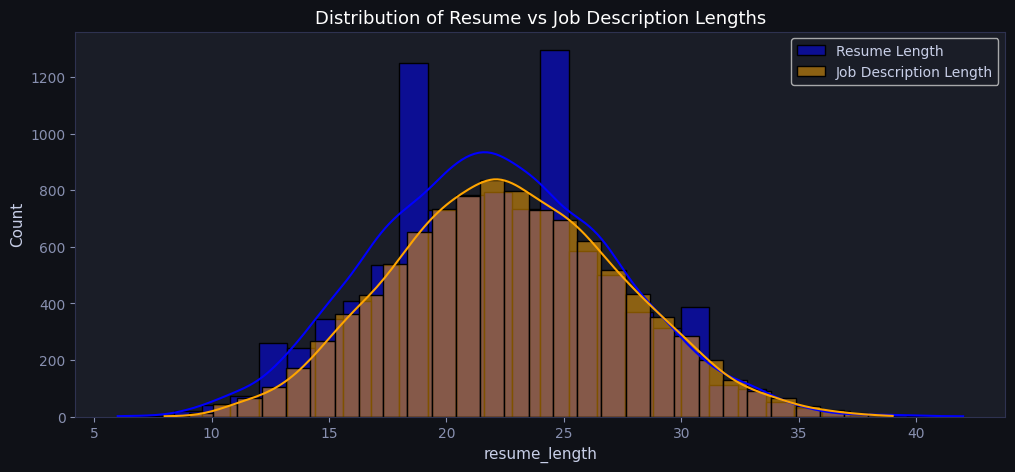

C:\Users\HELAL\AppData\Local\Temp\ipykernel_14976\2573459837.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="magma")


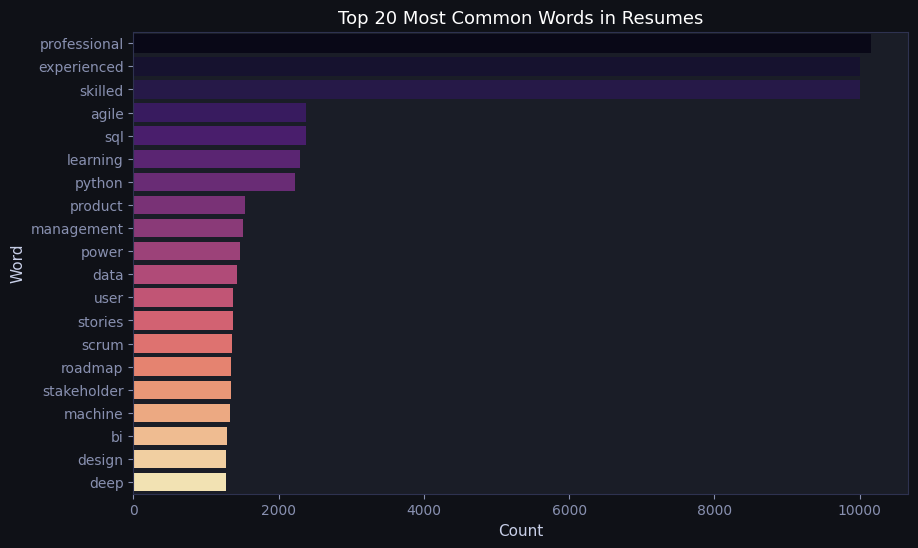

C:\Users\HELAL\AppData\Local\Temp\ipykernel_14976\2573459837.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


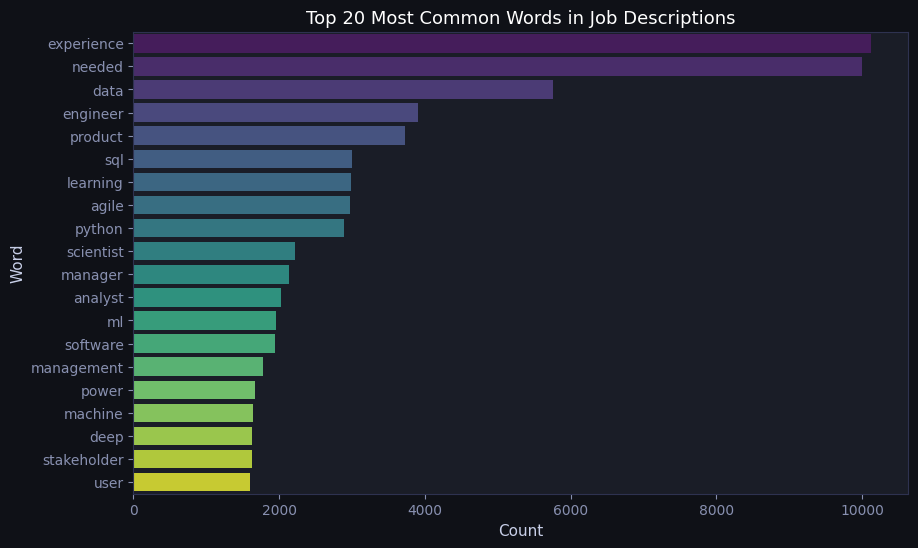

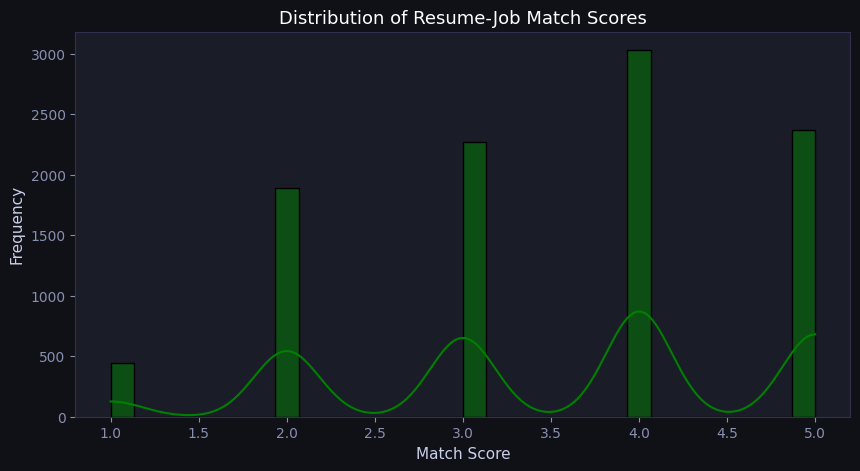

In [ ]:
# 6.1 Resume vs JD length distributions
df["resume_length"] = df["Cleaned_Resume"].apply(lambda x: len(x.split()))
df["jd_length"] = df["Cleaned_JD"].apply(lambda x: len(x.split()))

plt.figure(figsize=(12,5))
sns.histplot(df["resume_length"], bins=30, kde=True, color="blue", label="Resume Length")
sns.histplot(df["jd_length"], bins=30, kde=True, color="orange", label="Job Description Length")
plt.legend()
plt.title("Distribution of Resume vs Job Description Lengths")
plt.show()

# 6.2 Top 20 most common words in resumes
all_resume_text = " ".join(df["Cleaned_Resume"].astype(str).tolist())
resume_counts = Counter(all_resume_text.split()).most_common(20)

words, counts = zip(*resume_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette="magma")
plt.title("Top 20 Most Common Words in Resumes")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 6.3 Top 20 most common words in job descriptions
all_jd_text = " ".join(df["Cleaned_JD"].astype(str).tolist())
jd_counts = Counter(all_jd_text.split()).most_common(20)

words, counts = zip(*jd_counts)
plt.figure(figsize=(10,6))
sns.barplot(x=list(counts), y=list(words), palette="viridis")
plt.title("Top 20 Most Common Words in Job Descriptions")
plt.xlabel("Count")
plt.ylabel("Word")
plt.show()

# 6.4 Match score distribution
plt.figure(figsize=(10,5))
sns.histplot(df["match_score"], bins=30, kde=True, color="green")
plt.title("Distribution of Resume-Job Match Scores")
plt.xlabel("Match Score")
plt.ylabel("Frequency")
plt.show()


- TF-IDF Vectorization

In [ ]:
from preprocessing import clean_text
from sklearn.feature_extraction.text import TfidfVectorizer

# Ensure stopwords are downloaded
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Clean resumes
df["combined_text"] = df["Cleaned_Resume"] + " " + df["Cleaned_JD"]

# TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=1500)

X_tfidf = tfidf_vectorizer.fit_transform(df["combined_text"])
y = df["match_score"]  # or whichever column represents the category/score

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of TF-IDF matrix:", X_tfidf.shape)
print("Sample TF-IDF features:", tfidf_vectorizer.get_feature_names_out()[:10])
print("fasdfa;okfn")


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HELAL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Shape of TF-IDF matrix: (10000, 800)
Sample TF-IDF features: ['ability' 'able' 'accept' 'account' 'act' 'action' 'activity' 'actually'
 'add' 'address']
